Intro:

In [1]:
import pandas as pd
import numpy as np

np.random.seed(10)

df = pd.DataFrame({
    'fecha': pd.date_range('2025-01-01', periods=12, freq='M'),
    'region': np.random.choice(['Norte','Centro','Sur'], 12),
    'ventas': np.random.randint(2000,5000,12),
    'ticket_promedio': np.random.uniform(15,40,12),
    'reclamos': np.random.randint(20,150,12)
})

/tmp/ipykernel_523/1881151072.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  'fecha': pd.date_range('2025-01-01', periods=12, freq='M'),


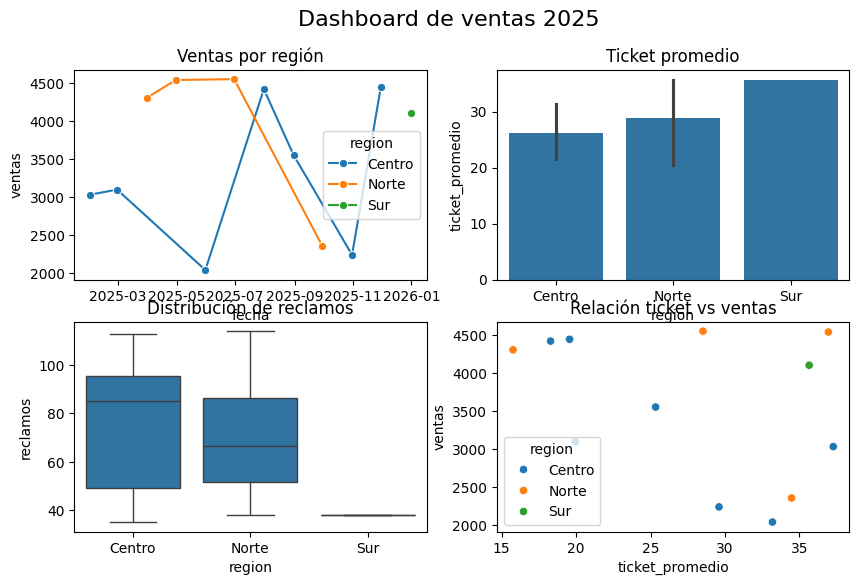

In [2]:
#Dashboard Recargado

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

plt.subplot(221)
sns.lineplot(data=df, x='fecha', y='ventas', hue='region', marker='o')
plt.title("Ventas por región")

plt.subplot(222)
sns.barplot(data=df, x='region', y='ticket_promedio')
plt.title("Ticket promedio")

plt.subplot(223)
sns.boxplot(data=df, x='region', y='reclamos')
plt.title("Distribución de reclamos")

plt.subplot(224)
sns.scatterplot(data=df, x='ticket_promedio', y='ventas', hue='region')
plt.title("Relación ticket vs ventas")

plt.suptitle("Dashboard de ventas 2025", fontsize=16)
plt.show()

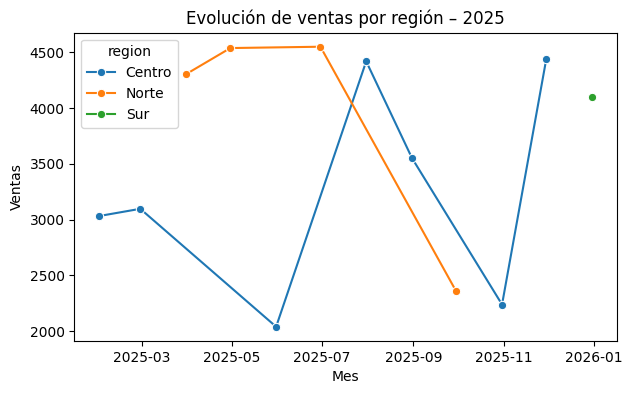

In [4]:
#Dashboard minimalista
plt.figure(figsize=(7,4))

sns.lineplot(data=df, x='fecha', y='ventas', hue='region', marker='o')

plt.title("Evolución de ventas por región – 2025")
plt.xlabel("Mes")
plt.ylabel("Ventas")

plt.show()

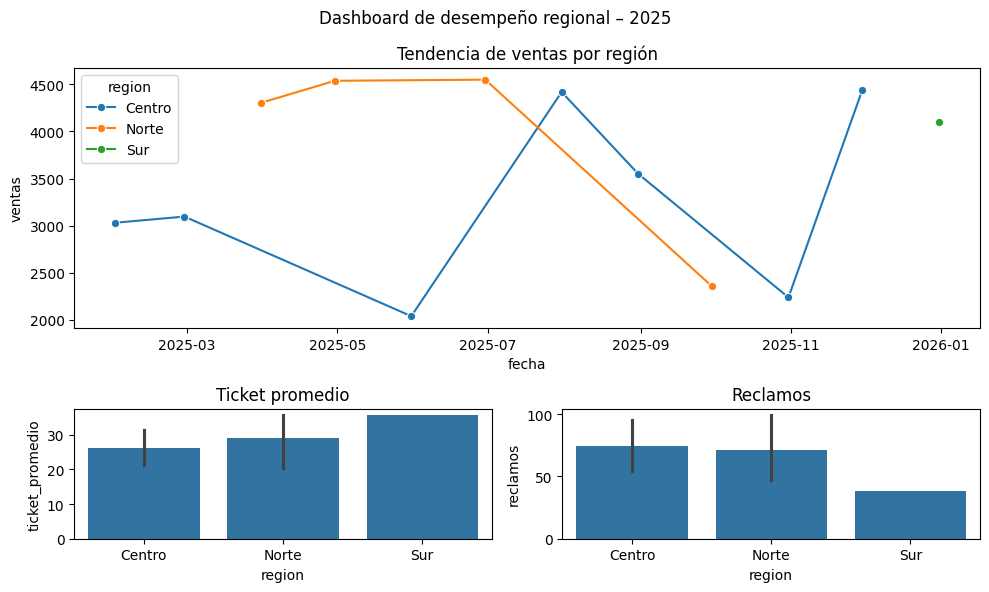

In [6]:
#Dashboard Jerarquizado
fig = plt.figure(figsize=(10,6))

gs = fig.add_gridspec(2,2, height_ratios=[2,1])

ax1 = fig.add_subplot(gs[0,:])
sns.lineplot(data=df, x='fecha', y='ventas', hue='region', marker='o', ax=ax1)
ax1.set_title("Tendencia de ventas por región")

ax2 = fig.add_subplot(gs[1,0])
sns.barplot(data=df, x='region', y='ticket_promedio', ax=ax2)
ax2.set_title("Ticket promedio")

ax3 = fig.add_subplot(gs[1,1])
sns.barplot(data=df, x='region', y='reclamos', ax=ax3)
ax3.set_title("Reclamos")

plt.suptitle("Dashboard de desempeño regional – 2025")

plt.tight_layout()
plt.show()

Actividad:

Propuesta de layout
1) Cabecera


Título principal:
Aumento de tiempos de entrega en 2025: diagnóstico y acciones

Subtítulo:
Evolución del SLA promedio, diferencias por región e impacto en satisfacción del cliente.

- KPI principal:

    * SLA promedio general

    * Región con peor SLA

    * NPS promedio general

2) Cuerpo principal

Tres vistas organizadas en bloque:

- Vista 1. Línea temporal

        Evolución mensual del sla_promedio

        Color por region

        Sirve para ver tendencia y quiebres

- Vista 2. Barras por región

        Promedio de SLA por región

        Ordenadas de mayor a menor

        Destacar con color acento la peor región

- Vista 3. Dispersión SLA vs NPS

        Eje X: sla_promedio

        Eje Y: nps

        Color por región

        Permite analizar si a mayor demora, menor satisfacción

3) Zona de soporte

Incluir un pequeño bloque tipo glosario:

    SLA promedio: horas promedio de entrega

    NPS: indicador de satisfacción del cliente

    Outlier: valor atípico que se desvía del patrón esperado

/tmp/ipykernel_523/12733.py:12: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  'fecha': pd.date_range('2025-01-01', periods=12, freq='M'),
/tmp/ipykernel_523/12733.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


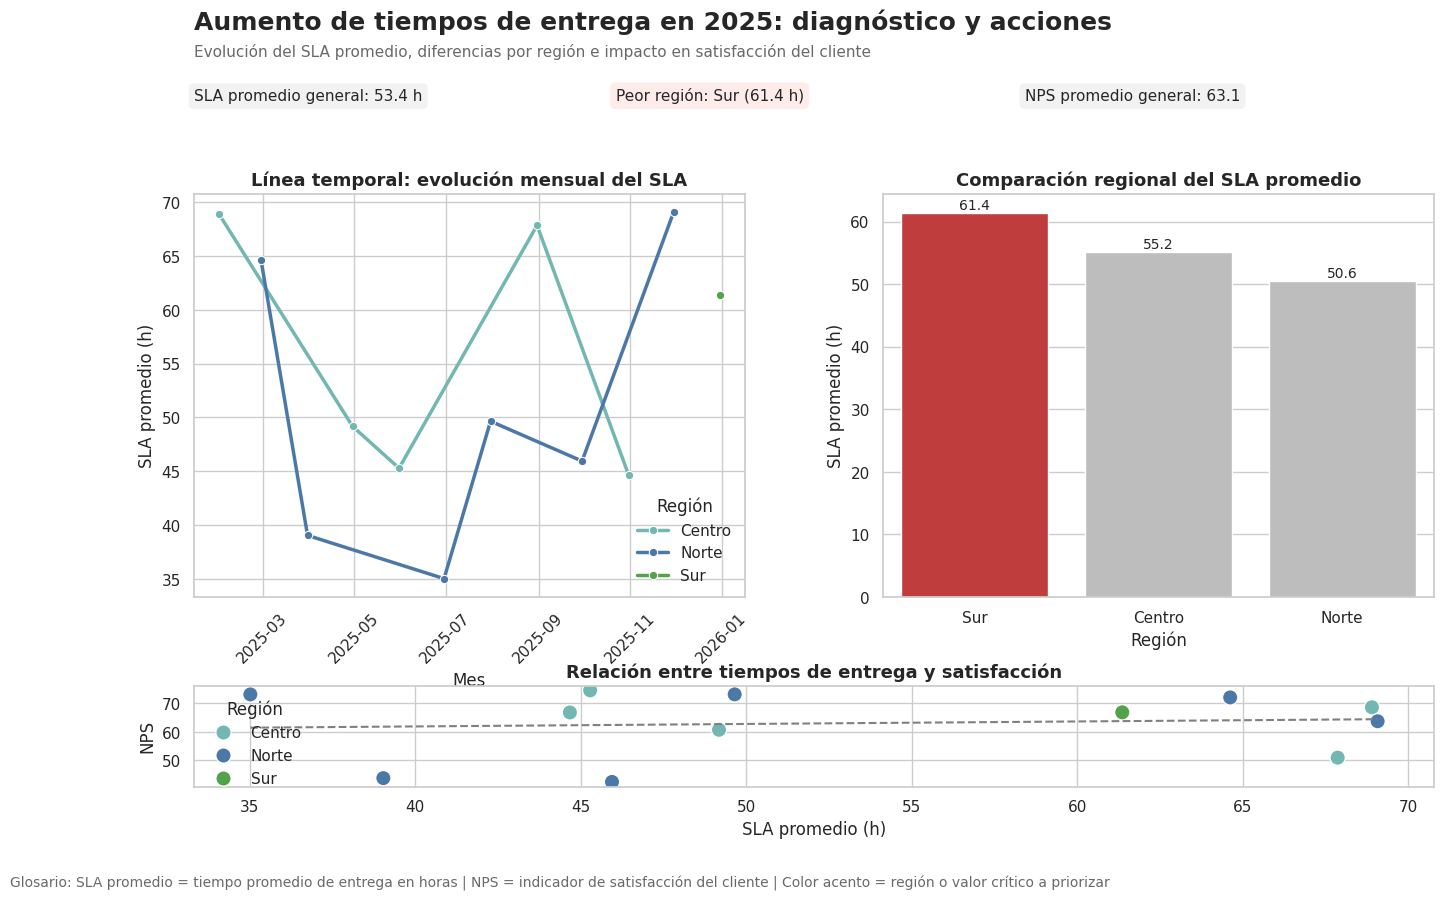

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------
# 1. Datos de ejemplo
# ---------------------------
np.random.seed(1)

df = pd.DataFrame({
    'fecha': pd.date_range('2025-01-01', periods=12, freq='M'),
    'region': np.random.choice(['Norte', 'Centro', 'Sur'], 12),
    'sla_promedio': np.random.uniform(24, 72, 12),
    'nps': np.random.uniform(40, 80, 12)
})

# ---------------------------
# 2. KPIs base
# ---------------------------
sla_general = df['sla_promedio'].mean()
nps_general = df['nps'].mean()

region_sla = (
    df.groupby('region', as_index=False)['sla_promedio']
    .mean()
    .sort_values('sla_promedio', ascending=False)
)

peor_region = region_sla.iloc[0]['region']
peor_sla = region_sla.iloc[0]['sla_promedio']

# ---------------------------
# 3. Estilo general
# ---------------------------
sns.set_theme(style="whitegrid")
accent_color = "#d62728"   # color acento para destacar
base_palette = {"Norte": "#4c78a8", "Centro": "#72b7b2", "Sur": "#54a24b"}

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 2, height_ratios=[0.22, 1, 0.25], hspace=0.45, wspace=0.25)

# ---------------------------
# 4. Cabecera
# ---------------------------
ax_title = fig.add_subplot(gs[0, :])
ax_title.axis("off")

titulo = "Aumento de tiempos de entrega en 2025: diagnóstico y acciones"
subtitulo = "Evolución del SLA promedio, diferencias por región e impacto en satisfacción del cliente"

ax_title.text(0.00, 0.85, titulo, fontsize=18, fontweight="bold", ha="left")
ax_title.text(0.00, 0.55, subtitulo, fontsize=11, color="dimgray", ha="left")

ax_title.text(0.00, 0.05, f"SLA promedio general: {sla_general:.1f} h", fontsize=11,
              bbox=dict(boxstyle="round,pad=0.35", facecolor="#f2f2f2", edgecolor="none"))
ax_title.text(0.34, 0.05, f"Peor región: {peor_region} ({peor_sla:.1f} h)", fontsize=11,
              bbox=dict(boxstyle="round,pad=0.35", facecolor="#fdecea", edgecolor="none"))
ax_title.text(0.67, 0.05, f"NPS promedio general: {nps_general:.1f}", fontsize=11,
              bbox=dict(boxstyle="round,pad=0.35", facecolor="#f2f2f2", edgecolor="none"))

# ---------------------------
# 5. Vista 1: Línea temporal
# ---------------------------
ax1 = fig.add_subplot(gs[1, 0])

sns.lineplot(
    data=df,
    x='fecha',
    y='sla_promedio',
    hue='region',
    marker='o',
    palette=base_palette,
    linewidth=2.5,
    ax=ax1
)

ax1.set_title("Línea temporal: evolución mensual del SLA", fontsize=13, fontweight="bold")
ax1.set_xlabel("Mes")
ax1.set_ylabel("SLA promedio (h)")
ax1.tick_params(axis='x', rotation=45)
ax1.legend(title="Región", frameon=False)

# ---------------------------
# 6. Vista 2: Barras por región
# ---------------------------
ax2 = fig.add_subplot(gs[1, 1])

colors = [
    accent_color if region == peor_region else "#bdbdbd"
    for region in region_sla['region']
]

sns.barplot(
    data=region_sla,
    x='region',
    y='sla_promedio',
    palette=colors,
    ax=ax2
)

ax2.set_title("Comparación regional del SLA promedio", fontsize=13, fontweight="bold")
ax2.set_xlabel("Región")
ax2.set_ylabel("SLA promedio (h)")

for i, val in enumerate(region_sla['sla_promedio']):
    ax2.text(i, val + 0.6, f"{val:.1f}", ha='center', fontsize=10)

# ---------------------------
# 7. Vista 3: Dispersión SLA vs NPS
# ---------------------------
ax3 = fig.add_subplot(gs[2, :])

sns.scatterplot(
    data=df,
    x='sla_promedio',
    y='nps',
    hue='region',
    palette=base_palette,
    s=120,
    ax=ax3
)

sns.regplot(
    data=df,
    x='sla_promedio',
    y='nps',
    scatter=False,
    ci=None,
    color='gray',
    line_kws={'linestyle': '--', 'linewidth': 1.5},
    ax=ax3
)

ax3.set_title("Relación entre tiempos de entrega y satisfacción", fontsize=13, fontweight="bold")
ax3.set_xlabel("SLA promedio (h)")
ax3.set_ylabel("NPS")
ax3.legend(title="Región", frameon=False, loc="best")

# ---------------------------
# 8. Glosario / soporte
# ---------------------------
fig.text(
    0.01, 0.01,
    "Glosario: SLA promedio = tiempo promedio de entrega en horas | "
    "NPS = indicador de satisfacción del cliente | "
    "Color acento = región o valor crítico a priorizar",
    fontsize=10, color="dimgray"
)

plt.show()